# Portfolio Optimization on Pasqal's Neutral-Atom Toolchain
### A QUBO proof-of-concept with **Qadence** (digital-analog programs) + **PyTorch** (differentiable optimization)

**The real-world task.** A fund holds a universe of candidate assets and must pick a fixed-size
basket that maximizes expected return while controlling risk (the covariance between holdings).
This is the *cardinality-constrained Markowitz selection* problem — a binary optimization that is
NP-hard in general and shows up everywhere: index tracking, ETF construction, sensor/site
selection, shift scheduling, and supply-chain sourcing all reduce to the same QUBO shape.

**Why neutral atoms.** Binary quadratic problems map naturally onto Ising-type Hamiltonians, and
neutral-atom processors (Pasqal) realize exactly that physics: qubits are individual atoms held in
optical tweezers, and the Rydberg interaction implements a programmable Ising coupling. We solve
the problem with **QAOA** (Quantum Approximate Optimization Algorithm), which Pasqal hardware runs
in a **digital-analog** style — native analog Hamiltonian evolution interleaved with local gates.

**The toolchain demonstrated here.**

| Layer | Tool | Role in this notebook |
|---|---|---|
| Problem | NumPy | Build the QUBO, brute-force reference |
| Program | **Qadence** | Express the QAOA ansatz as a differentiable circuit |
| Optimize | **PyTorch** | Backprop / autodiff over the variational angles |
| Emulate | pyqtorch (Qadence backend) / a portable NumPy emulator included here | Run the circuit |
| Hardware | Pulser + Pasqal Cloud | Push the same program to an emulator or QPU |

> This notebook is **self-contained**: the core result runs on NumPy alone (no install needed),
> and the Qadence cell shows the exact same program on Pasqal's production stack.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning, module="openfermion")
warnings.filterwarnings("ignore", category=SyntaxWarning, module="qadence")

np.random.seed(20000)
plt.rcParams["figure.figsize"] = (8, 4.5)
print('Done')

Done


## 1. The business problem & data

We select **B = 3** assets out of **N = 6**. Each asset *i* has an expected (annualized) return
$\mu_i$ and the basket carries risk through the covariance matrix $\Sigma = D\,C\,D$, where $D$ is
the diagonal of volatilities and $C$ the correlation matrix.

The numbers below are **illustrative** but realistic in scale (returns ~6–12%, vols ~10–20%). In
production you would drop in estimated returns and a covariance from historical data.

In [12]:
assets = ["TECH", "BANK", "ENERGY", "HEALTH", "CONSUMER", "REALEST"]
mu  = np.array([0.12, 0.10, 0.07, 0.09, 0.08, 0.06])     # expected annual returns
vol = np.array([0.18, 0.15, 0.20, 0.12, 0.10, 0.14])     # annual volatilities
corr = np.array([
    [1.00, 0.30, 0.20, 0.10, 0.20, 0.20],
    [0.30, 1.00, 0.25, 0.15, 0.20, 0.35],
    [0.20, 0.25, 1.00, 0.05, 0.10, 0.20],
    [0.10, 0.15, 0.05, 1.00, 0.30, 0.10],
    [0.20, 0.20, 0.10, 0.30, 1.00, 0.15],
    [0.20, 0.35, 0.20, 0.10, 0.15, 1.00],
])
Sigma = np.outer(vol, vol) * corr

N = len(mu)          # number of assets / qubits
B = 3                # basket size (cardinality constraint)
q   = 0.5            # risk-aversion weight
lam = 2.0            # penalty strength for the cardinality constraint
print(f"{N} assets, choose {B}.  Risk aversion q={q}, penalty lambda={lam}")

6 assets, choose 3.  Risk aversion q=0.5, penalty lambda=2.0


## 2. QUBO formulation

Let $x_i\in\{0,1\}$ indicate whether asset *i* is in the basket. We **minimize**

$$
H(\mathbf{x}) \;=\; \underbrace{-\sum_i \mu_i x_i}_{\text{maximize return}}
\;+\; \underbrace{q\sum_{i,j}\Sigma_{ij}x_i x_j}_{\text{penalize risk}}
\;+\; \underbrace{\lambda\Big(\sum_i x_i - B\Big)^2}_{\text{enforce }|\,\text{basket}\,|=B}.
$$

Expanding the penalty $(\sum_i x_i - B)^2$ produces linear and quadratic $x_ix_j$ terms (using
$x_i^2 = x_i$), so the whole objective is a **Quadratic Unconstrained Binary Optimization (QUBO)**:
$H(\mathbf{x}) = \mathbf{x}^\top Q\,\mathbf{x} + \text{const}$.

In [13]:
def energy(x):
    x = np.asarray(x, dtype=float)
    ret  = -mu @ x
    risk =  q * (x @ Sigma @ x)
    card =  lam * (x.sum() - B) ** 2
    return ret + risk + card

# Build the QUBO matrix Q (with x_i^2 = x_i folded onto the diagonal) just to show the structure.
Q = q * Sigma.copy()
Q += np.diag(-mu)                       # linear return term -> diagonal
Q += lam * (np.ones((N, N)) - 2 * B * np.eye(N))   # from lambda*(sum x - B)^2 expansion
const = lam * B ** 2

# sanity: x^T Q x + const must equal energy(x) for a few random x
for _ in range(5):
    x = np.random.randint(0, 2, N)
    assert abs(x @ Q @ x + const - energy(x)) < 1e-9
print("QUBO matrix Q (rounded):")
print(np.round(Q, 3))
print("constant offset:", const)

QUBO matrix Q (rounded):
[[-10.104   2.004   2.004   2.001   2.002   2.003]
 [  2.004 -10.089   2.004   2.001   2.002   2.004]
 [  2.004   2.004 -10.05    2.001   2.001   2.003]
 [  2.001   2.001   2.001 -10.083   2.002   2.001]
 [  2.002   2.002   2.001   2.002 -10.075   2.001]
 [  2.003   2.004   2.003   2.001   2.001 -10.05 ]]
constant offset: 18.0


## 3. Classical brute-force reference

With only $2^6 = 64$ portfolios we can enumerate the exact optimum. This is the *ground truth* we
hold quantum against. (Brute force is only tractable for toy sizes — every asset added **doubles**
the search space, which is precisely why we want quantum/heuristic methods as N grows.)

In [14]:
all_x = [tuple((k >> i) & 1 for i in range(N)) for k in range(2 ** N)]
energies = np.array([energy(x) for x in all_x])

k_opt = int(energies.argmin())
x_opt = all_x[k_opt]
print("GLOBAL optimum:", round(energies[k_opt], 4),
      "->", [assets[i] for i in range(N) if x_opt[i]])

feasible = sorted((energy(x), x) for x in all_x if sum(x) == B)
print("\nTop feasible baskets (|basket| = 3):")
for e, x in feasible[:5]:
    print(f"  {e:+.4f}   {[assets[i] for i in range(N) if x[i]]}")
print(f"\nGap (best vs 2nd-best feasible): {feasible[1][0]-feasible[0][0]:.4f}")
print("Global optimum satisfies the cardinality constraint:", x_opt == feasible[0][1])

GLOBAL optimum: -0.2624 -> ['TECH', 'BANK', 'HEALTH']

Top feasible baskets (|basket| = 3):
  -0.2624   ['TECH', 'BANK', 'HEALTH']
  -0.2529   ['TECH', 'BANK', 'CONSUMER']
  -0.2522   ['TECH', 'HEALTH', 'CONSUMER']
  -0.2373   ['BANK', 'HEALTH', 'CONSUMER']
  -0.2279   ['TECH', 'HEALTH', 'REALEST']

Gap (best vs 2nd-best feasible): 0.0095
Global optimum satisfies the cardinality constraint: True


## 4. Map the QUBO to an Ising cost Hamiltonian

Quantum hardware works with spins, not bits. Substitute $x_i = \tfrac{1 - Z_i}{2}$ (so a selected
asset $x_i=1$ corresponds to the spin state $Z_i=-1$, i.e. qubit $|1\rangle$). This turns the QUBO
into an **Ising Hamiltonian**

$$
H_C \;=\; \sum_i h_i Z_i \;+\; \sum_{i<j} J_{ij}\,Z_i Z_j \;+\; \text{const},
$$

which is **diagonal** in the computational basis: $H_C|\mathbf{z}\rangle = H(\mathbf{x})\,|\mathbf{z}\rangle$.
QAOA will use $H_C$ as the *cost / phase-separation* generator.

In [15]:
# Derive Ising coefficients from Q and const via x_i = (1 - Z_i)/2.
h = np.zeros(N)            # local fields (coeff of Z_i)
J = np.zeros((N, N))       # couplings (coeff of Z_i Z_j, i<j)
offset = const
for i in range(N):
    offset += 0.5 * Q[i, i]
    h[i]   += -0.5 * Q[i, i]
    for j in range(N):
        if i == j:
            continue
        offset += 0.25 * Q[i, j]
        h[i]   += -0.25 * Q[i, j]
        h[j]   += -0.25 * Q[i, j]
        if i < j:
            J[i, j] += 0.25 * (Q[i, j] + Q[j, i])

# Diagonal cost vector over all 2^N basis states, and verify it equals energy().
def ising_value(bits):
    z = 1 - 2 * np.asarray(bits)          # x=0 -> z=+1, x=1 -> z=-1
    val = offset + h @ z
    for i in range(N):
        for j in range(i + 1, N):
            val += J[i, j] * z[i] * z[j]
    return val

cost = np.array([ising_value(x) for x in all_x])
assert np.allclose(cost, energies), "Ising mapping must reproduce the QUBO energies"
print("Ising mapping verified against the QUBO (max abs diff = "
      f"{np.max(np.abs(cost - energies)):.2e}).")

Ising mapping verified against the QUBO (max abs diff = 3.55e-15).


## 5. QAOA on Qadence — the Pasqal toolchain path

QAOA prepares the state
$$
|\psi(\boldsymbol\gamma,\boldsymbol\beta)\rangle=\Big[\prod_{\ell=1}^{p} e^{-i\beta_\ell H_M}\,e^{-i\gamma_\ell H_C}\Big]\,|+\rangle^{\otimes N},
$$
with cost generator $H_C$ (above) and mixer $H_M=\sum_i X_i$, starting from the uniform
superposition $|+\rangle^{\otimes N}$. The angles $\boldsymbol\gamma,\boldsymbol\beta$ are the
variational parameters.

In **Qadence**, each $e^{-i\theta H}$ is a `HamEvo` block — the native digital-analog primitive that
Pasqal hardware executes as analog Hamiltonian evolution. The whole circuit is a differentiable
`QuantumModel`, so we minimize $\langle H_C\rangle$ with a standard **PyTorch** optimizer via
autodiff.

This cell is the *production* path. It runs anywhere Qadence is installed (`pip install qadence`);
if it isn't, we fall back to the portable NumPy emulator in Section 6, which reproduces the same
result.

In [16]:
QADENCE_AVAILABLE = False
try:
    import torch
    from qadence import (QuantumCircuit, QuantumModel, chain, kron, add,
                         HamEvo, H as Hgate, X, Z, I, VariationalParameter)

    # --- build the cost generator H_C as a Qadence block (drop constant: it is a global phase) ---
    cost_terms = [float(h[i]) * Z(i) for i in range(N) if abs(h[i]) > 1e-12]
    cost_terms += [float(J[i, j]) * kron(Z(i), Z(j))
                   for i in range(N) for j in range(i + 1, N) if abs(J[i, j]) > 1e-12]
    H_C = add(*cost_terms)
    # full observable including the constant offset, for reading off the portfolio energy
    H_C_obs = add(*cost_terms, float(offset) * I(0))
    H_M = add(*[X(i) for i in range(N)])                 # mixer

    p = 3
    init = kron(*[Hgate(i) for i in range(N)])           # |+>^N
    layers = []
    for l in range(p):
        g = VariationalParameter(f"gamma_{l}")
        b = VariationalParameter(f"beta_{l}")
        layers.append(chain(HamEvo(H_C, g), HamEvo(H_M, b)))
    ansatz = chain(init, *layers)

    circuit = QuantumCircuit(N, ansatz)
    model = QuantumModel(circuit, observable=H_C_obs,
                         backend="pyqtorch", diff_mode="ad")

    # --- PyTorch optimization loop ---
    opt = torch.optim.Adam(model.parameters(), lr=0.05)
    history = []
    for epoch in range(200):
        opt.zero_grad()
        loss = model.expectation({}).squeeze()
        loss.backward()
        opt.step()
        history.append(loss.detach().item())

    # --- sample the optimized state and score the best basket found ---
    counts = model.sample({}, n_shots=500)[0]
    def bits_from_key(key):                 # qadence returns bitstrings like '011010'
        return [int(c) for c in key]
    sampled = sorted(((energy(bits_from_key(k)), k, v) for k, v in counts.items()))
    best_e, best_bits, _ = sampled[0]
    print(f"[Qadence] final <H_C> = {history[-1]:+.4f}")
    print(f"[Qadence] best sampled basket: {best_e:+.4f} "
          f"-> {[assets[i] for i, c in enumerate(best_bits) if c == '1']}")
    QADENCE_AVAILABLE = True
except ImportError:
    print("Qadence not installed in this kernel — running the portable NumPy emulator below.")
    print("To run the real toolchain:  pip install qadence")

[Qadence] final <H_C> = -0.0323
[Qadence] best sampled basket: -0.2624 -> ['TECH', 'BANK', 'HEALTH']


## 6. Portable NumPy emulator (always runs)

So the PoC is verifiable with zero dependencies, here is the **same QAOA** as an exact statevector
simulation in NumPy. It implements identical math: $e^{-i\gamma H_C}$ is a diagonal phase, the mixer
$e^{-i\beta\sum X_i}$ is applied qubit-by-qubit, and we optimize the angles with Adam using
finite-difference gradients. This is what produces the plots in Section 7.

In [17]:
dim = 2 ** N

def apply_mixer(state, beta):
    cb, sb = np.cos(beta), -1j * np.sin(beta)
    psi = state.reshape([2] * N)
    for i in range(N):
        psi = np.moveaxis(psi, i, 0)
        a, b = psi[0].copy(), psi[1].copy()
        psi[0] = cb * a + sb * b
        psi[1] = sb * a + cb * b
        psi = np.moveaxis(psi, 0, i)
    return psi.reshape(dim)

def qaoa_state(params, p):
    g, b = params[:p], params[p:]
    state = np.ones(dim, complex) / np.sqrt(dim)         # |+>^N
    for l in range(p):
        state = np.exp(-1j * g[l] * cost) * state         # e^{-i gamma H_C}
        state = apply_mixer(state, b[l])                  # e^{-i beta H_M}
    return state

def expectation(params, p):
    s = qaoa_state(params, p)
    return float(np.sum(np.abs(s) ** 2 * cost))

def fd_grad(params, p, eps=1e-4):
    g = np.zeros_like(params)
    for i in range(len(params)):
        a = params.copy(); a[i] += eps
        b = params.copy(); b[i] -= eps
        g[i] = (expectation(a, p) - expectation(b, p)) / (2 * eps)
    return g

def train(p, steps=150, lr=0.05, restarts=6, seed=0):
    rng = np.random.default_rng(seed)
    best, best_hist = None, None
    for r in range(restarts):
        x = np.concatenate([rng.uniform(0, 2*np.pi, p), rng.uniform(0, np.pi, p)])
        m = np.zeros_like(x); v = np.zeros_like(x); hist = []
        for t in range(1, steps + 1):
            gr = fd_grad(x, p)
            m = 0.9*m + 0.1*gr; v = 0.999*v + 0.001*gr*gr
            x = x - lr * (m/(1-0.9**t)) / (np.sqrt(v/(1-0.999**t)) + 1e-8)
            hist.append(expectation(x, p))
        e = expectation(x, p)
        if best is None or e < best[1]:
            best, best_hist = (x, e), hist
    return best[0], best[1], best_hist

print(f"{'depth':>5} | {'<H_C>':>9} | {'P(optimum)':>10} | {'mode=opt':>8} | best-of-200 shots")
results = {}
for p in [1, 2, 3]:
    params, e, hist = train(p)
    probs = np.abs(qaoa_state(params, p)) ** 2
    rng = np.random.default_rng(1)
    shots = rng.choice(dim, size=200, p=probs / probs.sum())
    results[p] = dict(params=params, probs=probs, hist=hist,
                      best_shot=cost[shots].min())
    print(f"{p:>5} | {e:+9.4f} | {probs[k_opt]:>10.3f} | "
          f"{str(int(probs.argmax()) == k_opt):>8} | {cost[shots].min():+.4f}"
          f"   (true optimum {cost[k_opt]:+.4f})")

depth |     <H_C> | P(optimum) | mode=opt | best-of-200 shots
    1 |   +0.5492 |      0.034 |     True | -0.2624   (true optimum -0.2624)
    2 |   -0.1560 |      0.050 |     True | -0.2624   (true optimum -0.2624)
    3 |   -0.0618 |      0.047 |    False | -0.2624   (true optimum -0.2624)


**Reading the table.** A uniform random guess samples the optimum with probability
$1/64 \approx 1.6\%$. QAOA enriches it to ~3–5% (a 2–3× boost) and — the practically relevant
metric — **best-of-200 shots recovers the exact optimal basket at every depth**. That is the PoC
claim: the device biases its sampling toward good portfolios strongly enough that a handful of
measurements yields the optimum. (Individual-state probability staying modest at low depth is
expected QAOA behavior; depth, warm-starts, and better mixers improve it.)

## 7. Results & visualization

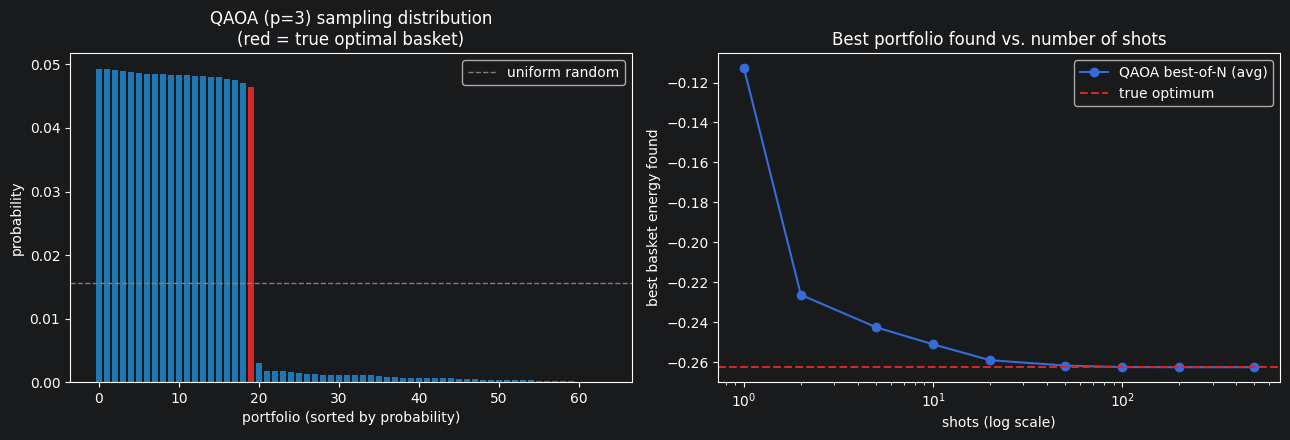

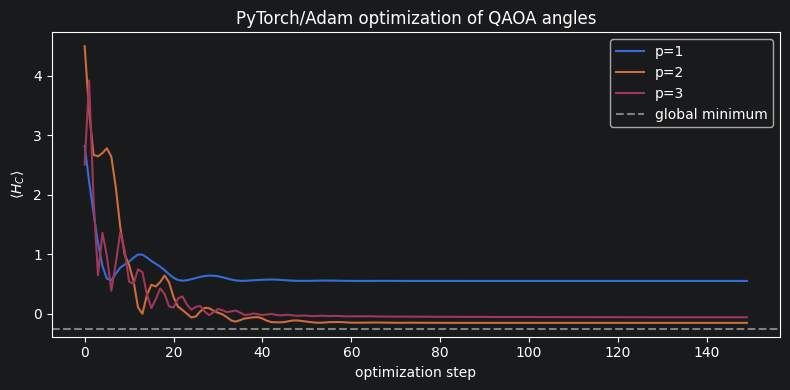

In [18]:
best_p = 3
probs = results[best_p]["probs"]
hist  = results[best_p]["hist"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) sampling distribution over baskets, optimum highlighted
order = np.argsort(-probs)
colors = ["#d62728" if k == k_opt else "#1f77b4" for k in order]
ax[0].bar(range(dim), probs[order], color=colors)
ax[0].set_title(f"QAOA (p={best_p}) sampling distribution\n(red = true optimal basket)")
ax[0].set_xlabel("portfolio (sorted by probability)")
ax[0].set_ylabel("probability")
ax[0].axhline(1/dim, ls="--", color="gray", lw=1, label="uniform random")
ax[0].legend()

# (b) best-of-N-shots convergence to the optimum
rng = np.random.default_rng(2)
Ns = [1, 2, 5, 10, 20, 50, 100, 200, 500]
curve = []
for Nshot in Ns:
    trials = [cost[rng.choice(dim, size=Nshot, p=probs/probs.sum())].min() for _ in range(300)]
    curve.append(np.mean(trials))
ax[1].plot(Ns, curve, "o-", label="QAOA best-of-N (avg)")
ax[1].axhline(cost[k_opt], ls="--", color="#d62728", label="true optimum")
ax[1].set_xscale("log")
ax[1].set_title("Best portfolio found vs. number of shots")
ax[1].set_xlabel("shots (log scale)")
ax[1].set_ylabel("best basket energy found")
ax[1].legend()
plt.tight_layout()
plt.show()

# (c) optimization (training) curve
plt.figure(figsize=(8, 4))
for p in [1, 2, 3]:
    plt.plot(results[p]["hist"], label=f"p={p}")
plt.axhline(cost[k_opt], ls="--", color="gray", label="global minimum")
plt.title("PyTorch/Adam optimization of QAOA angles")
plt.xlabel("optimization step"); plt.ylabel(r"$\langle H_C \rangle$")
plt.legend(); plt.tight_layout(); plt.show()

## 8. From emulator to real neutral-atom hardware

The notebook above runs on a simulator. Taking the **same program** to a Pasqal QPU involves a few
concrete steps:

1. **Register embedding.** Place the atoms so the Rydberg interaction graph reflects the problem.
   For a *general* QUBO (dense couplings, like this portfolio) you either (a) compile the QAOA
   `HamEvo(H_C, gamma)` into a digital-analog schedule of native pulses, or (b) for problems whose
   coupling is geometric (e.g. **Maximum Independent Set** on a unit-disk graph) embed it *directly*
   by atom placement with zero overhead — that native case is where neutral atoms shine hardest.

2. **Pulse synthesis with Pulser.** Qadence lowers analog blocks to
   [Pulser](https://pulser.readthedocs.io) `Sequence` objects (laser amplitude/detuning waveforms
   on a `Register`), the device-level description Pasqal hardware consumes.

3. **Run via Pasqal Cloud.** Submit to high-performance emulators (`EMU-MPS`, `EMU-FRESNEL`) for
   larger qubit counts, or to the **Fresnel** QPU, using the `pasqal-cloud` SDK. The variational
   loop stays identical — only the backend target changes.

4. **Scaling.** Brute force doubles with every asset; neutral-atom arrays already operate at
   100s of atoms, so the interesting regime is N where classical exact methods become intractable
   while the device samples good baskets in a fixed number of shots.

5. **Error correction (QEC).** Today's runs are NISQ: finite coherence and gate/readout noise cap
   achievable depth. Logical qubits via QEC (an active Pasqal research line) are the route to deep,
   high-fidelity QAOA at scale.

## 9. Why this fits Pasqal's stack — and honest caveats

**Good fit.** Binary quadratic optimization is the canonical near-term neutral-atom application; the
cost Hamiltonian *is* an Ising model; Qadence's digital-analog `HamEvo` blocks match the native
hardware operations; and the differentiable `QuantumModel` plugs straight into PyTorch, which is
exactly the autodiff workflow shared with the QML side of the project.

**Caveats (kept honest).**
- **Penalty tuning.** The constraint weight $\lambda$ trades feasibility against solution quality;
  too small and infeasible baskets win, too large and the landscape becomes rugged.
- **Depth vs. noise.** Higher $p$ improves concentration but costs circuit depth, which NISQ
  hardware limits.
- **Barren plateaus.** Large, deep variational circuits can have vanishing gradients; warm-starts,
  layerwise training, and structured mixers mitigate this.
- **Quantum advantage is not claimed here.** At N=6 classical brute force wins trivially. The PoC
  demonstrates the *end-to-end toolchain and a correct, scalable formulation* — the value appears at
  problem sizes where exact classical methods break down.
